In [9]:
# Uncomment this if you dont have any of the packages necessary

# !pip install mne numpy seaborn pandas wfdb scipy kaggle

In [1]:
import numpy as np
import os
import mne
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import butter, sosfiltfilt, sosfreqz, welch
import wfdb

import warnings
warnings.filterwarnings("ignore")

## Read Data into memory

In [2]:
os.environ['KAGGLE_USERNAME'] = 'matthewalegrado'
os.environ['KAGGLE_KEY'] = '00aa0dd972fc90dd7da344de4f29b618'

In [3]:
import kaggle
from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()
api.authenticate()

# Download dataset
dataset_name = "matthewalegrado/motor-imagery-dataset"
api.dataset_download_files(dataset_name, path=".", unzip=True)

Dataset URL: https://www.kaggle.com/datasets/matthewalegrado/motor-imagery-dataset


In [4]:
# Figure out which path to use, differs from .zip and wget download
subject = 1
trial = 1
try:
    file_path =  f"./files/eegmmidb/1.0.0/S{subject:03}/S{subject:03}R{trial:02}.edf"
    wfdb.rdann(file_path,'event')
    path = './files/eegmmidb/1.0.0/'
except FileNotFoundError:
    file_path =  f"./files/S{subject:03}/S{subject:03}R{trial:02}.edf"
    wfdb.rdann(file_path,'event')
    path = './files/'

In [5]:
def read_annotations(subject,trial):
    file_path =  path + f"/S{subject:03}/S{subject:03}R{trial:02}.edf"
    annotations = wfdb.rdann(file_path,'event')
    return annotations

In [ ]:
# Data parameters
num_subjects = 109
num_trials = 14
num_channels = 64
num_timepoints = 30000
subject_data = np.zeros((num_subjects,num_trials,num_channels,num_timepoints))

# Read all of our data into workspace
for subject in range(1, num_subjects+1):
    for trial in range(1,num_trials+1):
        # file = Path("./") / "files" / "eegmmidb" / "1.0.0" / f"S{subject:03}" / f"S{subject:03}R{trial:02}.edf" # Reads files of all subjects dynamically
        file = path + f'/S{subject:03}/S{subject:03}R{trial:02}.edf'
        try:
            with mne.io.read_raw_edf(file) as data:
                # Load data into subject_data np array
                raw_data = data.get_data()
                # Zero pad if this is a one-minute sample
                if raw_data.shape[1] != num_timepoints:
                    print(raw_data.shape)
                    subject_data[subject-1][trial-1] = np.pad(raw_data,((0,0),(0,num_timepoints - raw_data.shape[1])),'empty') # Add 9760 zero-padding to the right side of raw_data
                else:
                    subject_data[subject-1][trial-1] = raw_data
                # you can get the metadata included in the file and a list of all channels:
                info = data.info
                channels = data.ch_names
        except FileNotFoundError:
            print(f"{file} not found, skipping.")

Extracting EDF parameters from C:\Users\matta\Documents\GitHub\cogs-189\files\S001\S001R01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 9760)
Extracting EDF parameters from C:\Users\matta\Documents\GitHub\cogs-189\files\S001\S001R02.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 9760)
Extracting EDF parameters from C:\Users\matta\Documents\GitHub\cogs-189\files\S001\S001R03.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 20000)
Extracting EDF parameters from C:\Users\matta\Documents\GitHub\cogs-189\files\S001\S001R04.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 20000)
Extracting EDF parameters from C:\Users\matta\Documents\GitHub\cogs-189\files\S001\S001R05.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 20000)
Extracting EDF parameters from C:\Use

EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S009\S009R12.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S009\S009R13.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S009\S009R14.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S010\S010R01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 9760)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S010\S010R0

EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S012\S012R11.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S012\S012R12.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S012\S012R13.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S012\S012R14.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S013\S013R

EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S015\S015R10.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S015\S015R11.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S015\S015R12.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S015\S015R13.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S015\S015R

EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S018\S018R09.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S018\S018R10.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S018\S018R11.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S018\S018R12.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S018\S018R

...

EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S097\S097R10.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S097\S097R11.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S097\S097R12.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S097\S097R13.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S097\S097R

EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 15744)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S100\S100R09.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 15744)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S100\S100R10.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 15744)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S100\S100R11.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 15744)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S100\S100R12.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 15744)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S100\S100R

EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 20000)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S103\S103R08.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 20000)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S103\S103R09.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 20000)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S103\S103R10.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 20000)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S103\S103R11.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 20000)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S103\S103R

EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 20000)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S106\S106R07.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 20000)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S106\S106R08.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 20000)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S106\S106R09.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 20000)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S106\S106R10.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 20000)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S106\S106R

EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S109\S109R06.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S109\S109R07.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S109\S109R08.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S109\S109R09.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
(64, 19680)
Extracting EDF parameters from C:\Users\matta\OneDrive\Documents\GitHub\cogs-189\files\S109\S109R

In [ ]:
subject_data.shape

In [ ]:
info

In [ ]:
fs = 160

In [ ]:
channels

### Read the annotations file for event timesteps

In [ ]:
import wfdb

# Specify the path to the .event file (without the extension)
# file_path = Path("./") / "files" / "eegmmidb" / "1.0.0" / f"S{subject:03}" / f"S{subject:03}R{trial:02}.edf.event" # Reads files of all subjects dynamically
subject = 1
trial = 3

file_path = path + f"S{subject:03}/S{subject:03}R{trial:02}.edf"
annotations = wfdb.rdann(file_path,'event')

# Print annotation sample times
print(annotations.sample)

# Print annotation labels
print(annotations.symbol)

### Look at subject 1's trials 3 and 4 as an example
Trial 3 is moving left and right fist, trial 4 is imagining moving those fists

In [ ]:
# Example time plot of the 64 channel data
motor_channels = ['C4..','C3..','Cz..']
df = pd.DataFrame(subject_data[0][2].T,columns=channels)  # Transpose to have 64 channels as columns
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# # Plot the data using seaborn
# sns.set(style="whitegrid")
# plt.figure(figsize=(10, 6))

# # Create a line plot for each channel
# sns.lineplot(data=df[df.columns == motor_channels], dashes=False)

# Select the columns from the DataFrame
selected_channels = df[motor_channels]

# Plot the selected channels using seaborn
sns.lineplot(data=selected_channels)

for x in annotations.sample:
    plt.axvline(x=x, color='r', linestyle='--', label=f'x = {x}')

plt.xlim(0, annotations.sample[3])
    
plt.title("Real Trial")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

In [ ]:
motor_channels = ['C4..','C3..','Cz..']
df = pd.DataFrame(subject_data[0][3].T,columns=channels)  # Transpose to have 64 channels as columns

selected_channels = df[motor_channels]

subject = 1
trial = 4
file_path = path + f"S{subject:03}/S{subject:03}R{trial:02}.edf"

# Read the annotation file
annotations = wfdb.rdann(file_path,'event')

# Plot the selected channels using seaborn
sns.lineplot(data=selected_channels)

for x in annotations.sample:
    plt.axvline(x=x, color='r', linestyle='--', label=f'x = {x}')

plt.xlim(0, annotations.sample[3])

plt.title("Imaginary trial")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

### Filter the two trials, looking at motor, parietal, and frontal cortex

In [ ]:
def butter_bandpass(lowcut, highcut, fs, order = 2):
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq
        sos = butter(order, [low, high], analog = False, btype = 'band', output = 'sos')
        return sos

In [ ]:
def plot_filtered_trial(subject_data, subject=1, trial=3, epoch_len=4, epoch_start=None,
                    motor_channels=['C4..','C3..','Cz..'],plot_title="Title"):
    """
    Display 3-plot of a given subject and trial using bandpass filter on Alpha, Beta, and Gamma ranges.
    For event colors, T0 is green, T1 is red, T2 is cyan.

    Args:
        subject_data (np.array): The dataset we are working with.
        subject (int): Which subject to look at (1-indexed).
        trial (int): Which subject to look at (1-indexed).
        epoch_len (int): How many epochs to look at, where one epoch is one target (T0,T1,T2).
        epoch_start (int): Which epoch to start at.
        motor_channels (list of str): Which channels to look at. Refer to the printed channels variable in cell above 
            for the list.
        plot_title (str): Title of the full figure.
        
    Returns: nothing
    """
   
    num_channels = len(motor_channels)
    
    df = pd.DataFrame(subject_data[subject-1][trial-1].T,columns=channels)  # Transpose to have 64 channels as columns

    # Create a figure and a set of subplots (e.g., 2 rows, 2 columns)
    fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12,12))
    
    # Read the annotation file
    file_path =  path + f"S{subject:03}/S{subject:03}R{trial:02}.edf"
    annotations = wfdb.rdann(file_path,'event')
    samples = annotations.sample
    notes = annotations.aux_note

    selected_channels = df[motor_channels]

    sos_alpha = butter_bandpass(8, 12, fs, order = 10)
    sos_beta = butter_bandpass(13, 30, fs, order = 10)
    sos_gamma = butter_bandpass(30, 79, fs, order = 10)

    alpha_df = selected_channels.apply(lambda x: sosfiltfilt(sos_alpha, x))
    beta_df = selected_channels.apply(lambda x: sosfiltfilt(sos_beta, x))
    gamma_df = selected_channels.apply(lambda x: sosfiltfilt(sos_gamma, x))

    sns.lineplot(data=alpha_df,ax=axes[0])
    sns.lineplot(data=beta_df,ax=axes[1])
    sns.lineplot(data=gamma_df,ax=axes[2])

    titles = ['Alpha (8-12 Hz)','Beta (13-30 Hz)','Gamma (30-79 Hz)']

    for sample, note in zip(samples,notes):        
        if 'T0' in note:
            color = 'g'
        elif 'T1' in note:
            color = 'r'
        elif 'T2' in note:
            color = 'c'
        else:
            color = 'y'

        for i in range(3):
            if epoch_start is None or type(epoch_start) is not int:
                axes[i].set_xlim(0, samples[epoch_len-1]+20)
            else:
                axes[i].set_xlim(annotations.sample[epoch_start-1]-20, annotations.sample[epoch_start + epoch_len - 1]+20)
            axes[i].axvline(x=sample, color=color, linestyle='--', label=f't = {x}')
            axes[i].set_title(titles[i])

    plt.suptitle(plot_title, fontsize=16)
    plt.xlabel("Timesteps")
    plt.ylabel("Amplitude")
    plt.tight_layout()  # Adjust spacing between subplots
    plt.show()

In [ ]:
# Control whether to show or hide the big list of filtered time plots
time_plots = True

In [ ]:
# filtered_trial is one-indexed, so for subject 001, you'd put subject=1 and whichever trial you wanted to look at. The 
# motor_channels can be selected, so you could add for example the channel 'Cz..' if you wanted, all of the channels are
# strings of length 4, padded with 1 or 2 periods at the end.
if time_plots:
    plot_filtered_trial(
        subject_data,
        subject=1,
        trial=3,
        motor_channels=['C4..','C3..'],
        epoch_start=1,
        plot_title="Real Hand Trial Filtered along Alpha, Beta, Gamma bands")

In [ ]:
if time_plots:
    plot_filtered_trial(
        subject_data,
        subject=1,
        trial=3,
        motor_channels=['Cp3.','Cp4.'],
        plot_title="Real Hand Trial Filtered along Alpha, Beta, Gamma bands")

In [ ]:
if time_plots:
    plot_filtered_trial(
        subject_data,
        subject=1,
        trial=3,
        motor_channels=['Fc3.','Fc4.'],
        plot_title="Real Hand Trial Filtered along Alpha, Beta, Gamma bands")

In [ ]:
if time_plots:
    plot_filtered_trial(
        subject_data,
        subject=1,
        trial=4,
        motor_channels=['C4..','C3..'],
        plot_title="Imaginary Hand Trial Filtered along Alpha, Beta, Gamma bands")

In [ ]:
if time_plots:
    plot_filtered_trial(
        subject_data,
        subject=1,
        trial=4,
        motor_channels=['Cp3.','Cp4.'],
        plot_title="Imaginary Hand Trial Filtered along Alpha, Beta, Gamma bands")

In [ ]:
if time_plots:
    plot_filtered_trial(
        subject_data,
        subject=1,
        trial=4,
        motor_channels=['Fc3.','Fc4.'],
        plot_title="Imaginary Hand Trial Filtered along Alpha, Beta, Gamma bands")

## SVM Classifier and CSP filtering
This section explores the effect of the SVM classifier with and without CSP filtering. I formatted the data with labels of each epoch being either from the imaginary or the real trial. Each epoch has SxC features, where S is the number of samples in the 4 seconds after each T-code, and C is the number of channels.

The SVM trained on unfiltered data seemed to be up to or somehow worse than chance, while selecting appropriate channels to run CSP on made the classifier actually have a higher than chance accuracy, but it varied a lot based on which channels are chosen. If we choose to focus on the 8-12 Hz band, the accuracy goes up significantly, even without using CSP, at around 70% accuracy.

In [61]:
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [62]:
def format_data(data, subject, selected_channels='all', filter_bands=None):
    """
    Format training/testing data into a 2d array of size (E, SxC), where S is how many samples there are in 
    one event (+1 since the label is at index 0), C is the number of channels, and E is the number of 
    non-resting events. Each E will correspond to one sample for the SVM.
    
    Inputs:
        data (np.array): The 3-d data for a single subject, or the 4-d data for all subjects.
        subject (int): Which subject the data belongs to.
        selected_channels (optional, list or str): Which EEG channels to look at. Defaults to 'all'
        filter_bands (optional, tuple): The passbands for the filter.
    
    Returns: 
        formatted_data (np.array): The formatted data, in size (E, SxC).
        labels (list): The labels with -1 for imaginary and 1 for real movements.
    """
    df_list = []
    if selected_channels == 'all':
        selected_channels = channels  # Use channels global var for all channel selection
    if len(data.shape) > 3:
        data = data[subject-1]
        
    fs = 160
    if filter_bands is not None:
        lowcut, highcut = filter_bands
        sos = butter_bandpass(lowcut, highcut, fs, order = 10)
        
    for trial in data:
        df = pd.DataFrame(trial.T,columns=channels)
        if filter_bands is not None:
            df = df.apply(lambda x: sosfiltfilt(sos, x))
        df_list.append(df)

    time_between_codes = 4
    fs = 160
    samples_between_codes = fs*time_between_codes

    imaginary_vs_real = {}
    for i in range(3,15):
        if i % 2 == 1:
            imaginary_vs_real[i] = 'real'
        else:
            imaginary_vs_real[i] = 'imaginary'

    trial_iter = 1
    formatted_data = None
    labels = []
    
    for trial in df_list:
        try:
            # Label 1 as a real trial, 0 as imaginary trial
            if 'real' in imaginary_vs_real[trial_iter]:
                label = 1
            elif 'imaginary' in imaginary_vs_real[trial_iter]: 
                label = -1
            else:
                continue  # Skip the baselines, TODO check if we should use baselines somehow
        except KeyError:
#             print('Key',trial_iter,'not detected, skipping...')
            trial_iter += 1
            continue

        annotations = read_annotations(subject,trial_iter)
        events = annotations.sample
        codes = annotations.aux_note

    #     T0 = [(sample,aux_note) for (sample,aux_note) in zip(events,codes) if 'T0' in aux_note]
        T1 = [(sample,aux_note) for (sample,aux_note) in zip(events,codes) if 'T1' in aux_note]
        T2 = [(sample,aux_note) for (sample,aux_note) in zip(events,codes) if 'T2' in aux_note]

        # For given trial, extract T1 and T2 events, then format them for output
        
        for event,_ in T1:  # samples x channels x epochs (each event/epoch gets 1 row)
            new_data = trial[event:event+samples_between_codes][selected_channels]  # samples x channels
            output_data = np.array(new_data)
            sz_1,sz_2 = output_data.shape
            output_data = np.reshape(output_data,(sz_1,sz_2,1))  # Turn into 3d array
        
            labels.append(label)

            if formatted_data is None:
                formatted_data = output_data
            else:
                formatted_data = np.concatenate([formatted_data, output_data],axis=2)
                
        for event,_ in T2:  # samples x channels x epochs (each event/epoch gets 1 row)
            new_data = trial[event:event+samples_between_codes][selected_channels]  # samples x channels
            output_data = np.array(new_data)
            sz_1,sz_2 = output_data.shape
            output_data = np.reshape(output_data,(sz_1,sz_2,1))  # Turn into 3d array
        
            labels.append(label)

            if formatted_data is None:
                formatted_data = output_data
            else:
                formatted_data = np.concatenate([formatted_data, output_data],axis=2)

        trial_iter += 1
    
    # Currently shaped (S,C,E), reshape to (E, SxC)
    S,C,E = formatted_data.shape
    return np.reshape(formatted_data,(E,S*C)), labels

Model Accuracy: 0.7167

Confusion Matrix:
 [[20 11]
 [ 6 23]]

Classification Report:
               precision    recall  f1-score   support

          -1       0.77      0.65      0.70        31
           1       0.68      0.79      0.73        29

    accuracy                           0.72        60
   macro avg       0.72      0.72      0.72        60
weighted avg       0.72      0.72      0.72        60



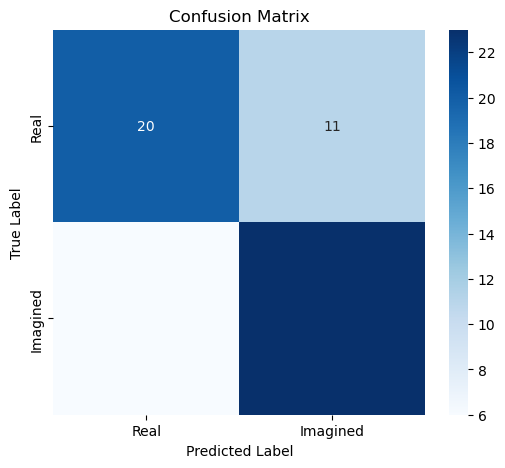

In [63]:
# SVM without CSP
subject = 1
selected_channels = ['Cz..','C4..','C3..','Cp4.','Cp3.']

output, labels = format_data(subject_data[subject-1], subject, selected_channels=selected_channels, filter_bands=(8,12))

X_train, X_test, y_train, y_test = train_test_split(
    output, labels, test_size=0.33, random_state=42)

clf = svm.SVC()
clf.fit(X_train, y_train)

predictions = clf.predict(X_test)
results = np.multiply(predictions,y_test)  # Find errors

# Evaluate Model Performance
accuracy = accuracy_score(y_test, predictions)
conf_matrix = confusion_matrix(y_test, predictions)
class_report = classification_report(y_test, predictions)

print(f"Model Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

# **Plot Confusion Matrix**
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d",
            xticklabels=["Real", "Imagined"], yticklabels=["Real", "Imagined"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [64]:
import mne
from mne.decoding import CSP
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

mne.set_log_level('ERROR')

def filter_csp(data,subject,selected_channels='all',filter_bands=None,csp_n_components=4):
    """
    Do CSP filtering on the data of a given subject, along selected channels with optional filtering. 

    Inputs:
        data (np.array): The 3-d data for a single subject, or the 4-d data for all subjects
        subject (int): Which subject the data belongs to.
        selected_channels (optional, list or str): Which EEG channels to look at. Defaults to 'all'
        filter_bands (optional, tuple): The passbands for the filter.
        csp_n_components (optional, int): How many features the CSP extraction will output.

    Returns: 
        X_csp: A numpy array of CSP'd data.
        labels: The corresponding labels for X_csp.
    """
    if selected_channels == 'all':
        selected_channels = channels  # Use channels global var for all channel selection
    if len(data.shape) > 3:
        data = data[subject-1]
    # Get outputs in (E,SxC) shape and reshape to (E,C,S) for CSP
    output, labels = format_data(data, subject, selected_channels=selected_channels, filter_bands=filter_bands)
    
    E,SxC = output.shape
    C = len(selected_channels)
    S = int(SxC / C)
    epochs = np.reshape(output,(E,C,S))
    
    # Suppose you have your epochs (n_epochs, channels, samples) and labels in arrays
    # Create an info dictionary (adjust channel names and sampling rate as needed)
    fs = 160  # sampling frequency in Hz
    ch_types = ['eeg'] * C
    info = mne.create_info(ch_names=selected_channels, sfreq=fs, ch_types=ch_types)
    
    events = np.column_stack((
        np.arange(0, E * fs*4, fs*4), 
        np.zeros(E, dtype=int),                         
        np.zeros(E, dtype=int)                    
    ))
    # print(events.shape)
    events[:,2] = labels
    
    # Create an MNE EpochsArray (here, we assign arbitrary times, adjust if needed)
    epochs_mne = mne.EpochsArray(epochs, info, event_id=labels, events=events)

    # Convert your event labels into integer codes
    le = LabelEncoder()
    y = le.fit_transform(labels)
    
    # Apply CSP (e.g., select 4 components)
    csp = CSP(n_components=csp_n_components, reg=None, log=True, norm_trace=False)
    X_csp = csp.fit_transform(epochs_mne.get_data(), y)
    
    return X_csp, labels

def deploy_svm(data,labels,test_size=.33,plotting=True,subject=None):
    """
    Train and test on a support vector machine given the original data and labels. Automatically does train-test splitting.
    Optionally will print the confusion matrix.

    Inputs:
        data (np.array): The data to train and test on.
        labels (list): The list of labels for the data.
        test_size (float): The proportion of test data to train data.
        plotting (bool): Whether or not to plot the confusion matrix.
        subject (int): Which subject to print on the plot.

    Returns: 
        error: The error on the test set.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        data, labels, test_size=test_size)
    
    clf = svm.SVC()
    clf.fit(X_train, y_train)
    
    predictions = clf.predict(X_test)
    
    # Evaluate Model Performance
    accuracy = accuracy_score(y_test, predictions)
    conf_matrix = confusion_matrix(y_test, predictions)
    class_report = classification_report(y_test, predictions)
    
    # **Plot Confusion Matrix**
    if plotting:
        print(f"Model Accuracy: {accuracy:.4f}")
        # print("\nConfusion Matrix:\n", conf_matrix)
        # print("\nClassification Report:\n", class_report)
    
        plt.figure(figsize=(6, 5))
        sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d",
                    xticklabels=["Real", "Imagined"], yticklabels=["Real", "Imagined"])
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.title(f"Confusion Matrix for Subject {subject}")
        plt.show()

    return accuracy

Model Accuracy: 0.8167


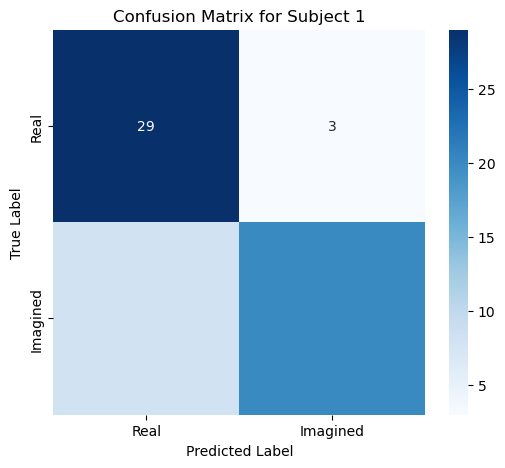

0.8166666666666667

In [65]:
# Example on using CSP and SVM together
subject = 1

X_csp, labels = filter_csp(subject_data[subject-1],subject,filter_bands=(8,12))
deploy_svm(X_csp,labels,plotting=True,subject=subject)

### Plotting SVM results with different filtering and CSP on various channel combinations

In [120]:
def plot_svm_accuracy(data,test_channels=['all'],subject_range=3,filter_bands=None,csp=False):
    bands = {(8,12):'alpha',(13,30):'beta',(30,79):'gamma'}
    accuracy_list = []
    channels_list = []
    subject_count = subject_range

    for selected_channels in test_channels:
        if selected_channels == 'all':
            channels_list.append(selected_channels)
        else:
            channels_list.append("/".join(selected_channels).replace(".", ""))

    for subject in range(1,subject_range+1):
        exception = False
        accuracy = []
        for selected_channels in test_channels:
            try:
                if csp:
                    X_csp, labels = filter_csp(subject_data,subject,selected_channels=selected_channels,filter_bands=filter_bands)
                    acc = deploy_svm(X_csp,labels,plotting=False,subject=subject)
                else:
                    X, labels = format_data(subject_data,subject,selected_channels=selected_channels,filter_bands=filter_bands)
                    acc = deploy_svm(X,labels,plotting=False,subject=subject)
            except np.linalg.LinAlgError:
                exception = True
                break

            accuracy.append(acc)

        if exception:
            print(f'Exception thrown for subject {subject}')
            subject_count -= 1
            continue

        accuracy = np.array(accuracy)
        accuracy_list.append(accuracy)

    df = pd.DataFrame(np.array(accuracy_list))
    df.columns = channels_list
    df_melted = df.melt(var_name='Channels', value_name='Accuracy')
    
    plt.figure(figsize=(10, 6))

    for i in range(len(channels_list)):
        sns.barplot(x='Channels', y='Accuracy', data=df_melted, errorbar='sd', capsize=0.1, palette='Blues')

    if filter_bands in bands and csp:
        plt.title(f"Accuracy of {bands[filter_bands]}-filtered, CSP based SVM classification vs. channel selection")
    elif csp:
        plt.title(f"Accuracy of CSP based SVM classification vs. channel selection")
    elif filter_bands in bands:
        plt.title(f"Accuracy of {bands[filter_bands]}-filtered SVM classification vs. channel selection")
    else:
        plt.title(f"Accuracy of SVM classification vs. channel selection")

    plt.tight_layout()
    plt.show()
    print(f'Tested on {subject_count} subjects')

In [124]:
bands = {'alpha':(8,12),'beta':(13,30),'gamma':(30,79)}

# Modify these to try different combinations
test_channels = [
    'all',
    ['Cz..','C4..','C3..','Cp4.','Cp3.','Fc3.','Fc4.','Fcz.'],
    ['Cz..','C4..','C3..']
]

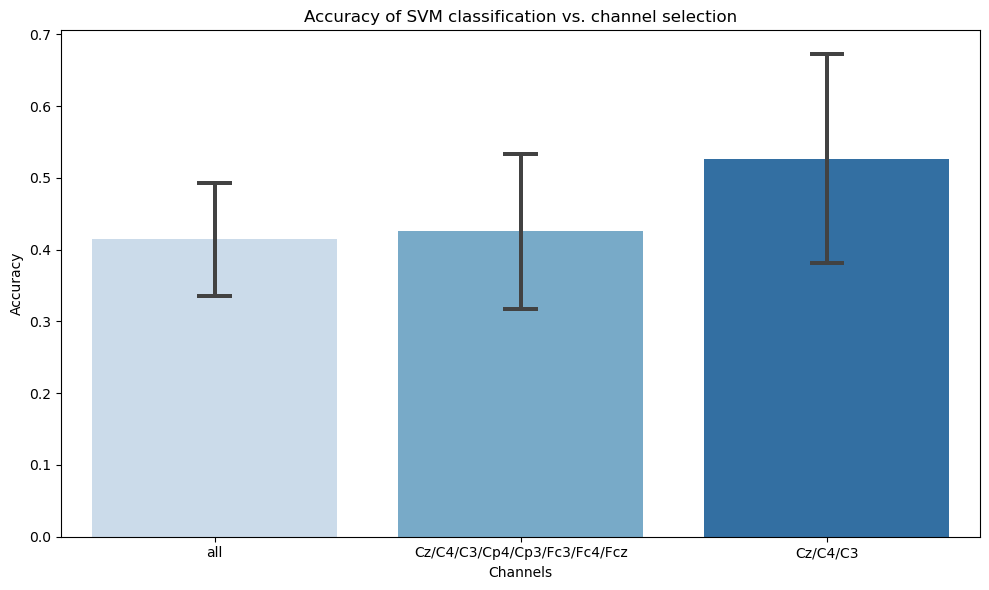

Tested on 109 subjects


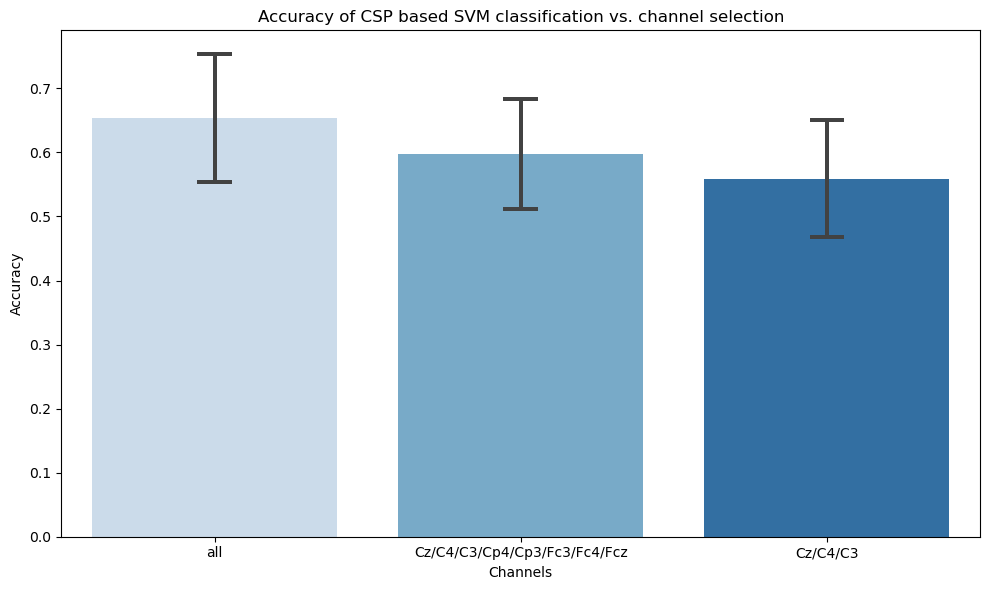

Tested on 109 subjects


In [125]:
plot_svm_accuracy(subject_data,test_channels=test_channels,subject_range=109)
plot_svm_accuracy(subject_data,test_channels=test_channels,subject_range=109,csp=True)

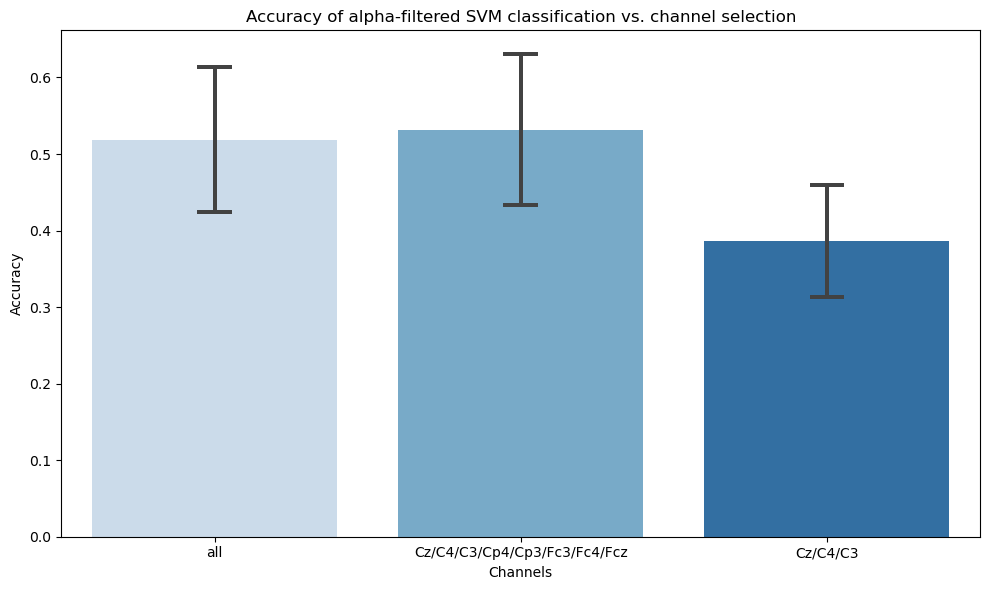

Tested on 109 subjects
Exception thrown for subject 88
Exception thrown for subject 92


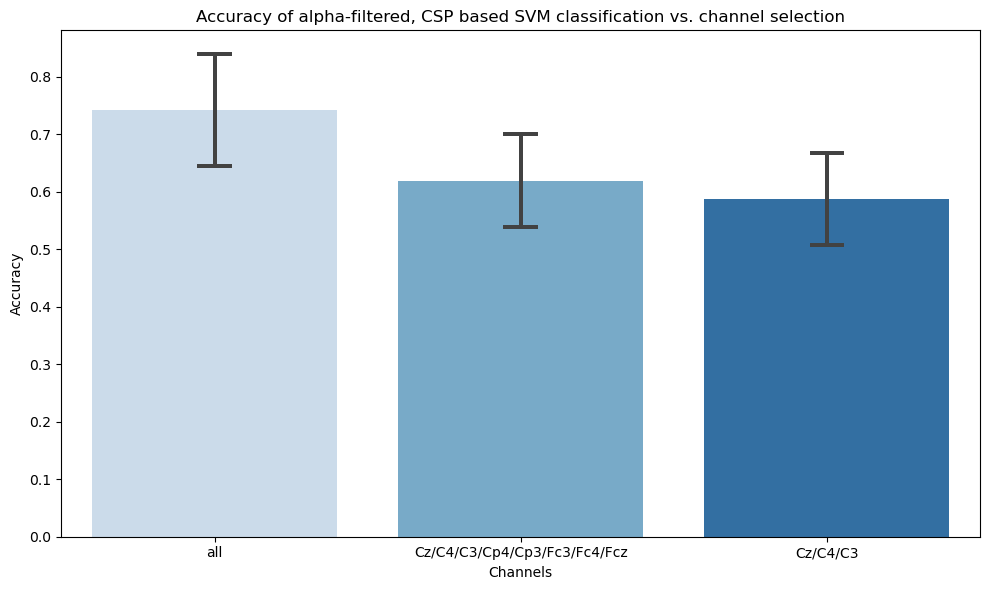

Tested on 107 subjects


In [126]:
plot_svm_accuracy(subject_data,test_channels=test_channels,filter_bands=bands['alpha'],subject_range=109)
plot_svm_accuracy(subject_data,test_channels=test_channels,filter_bands=bands['alpha'],csp=True,subject_range=109)

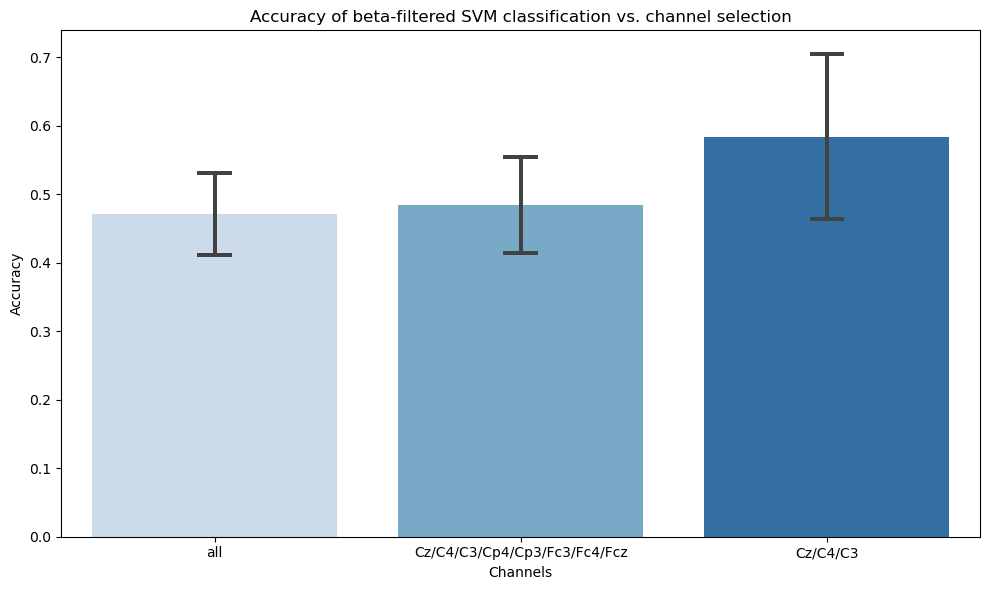

Tested on 109 subjects


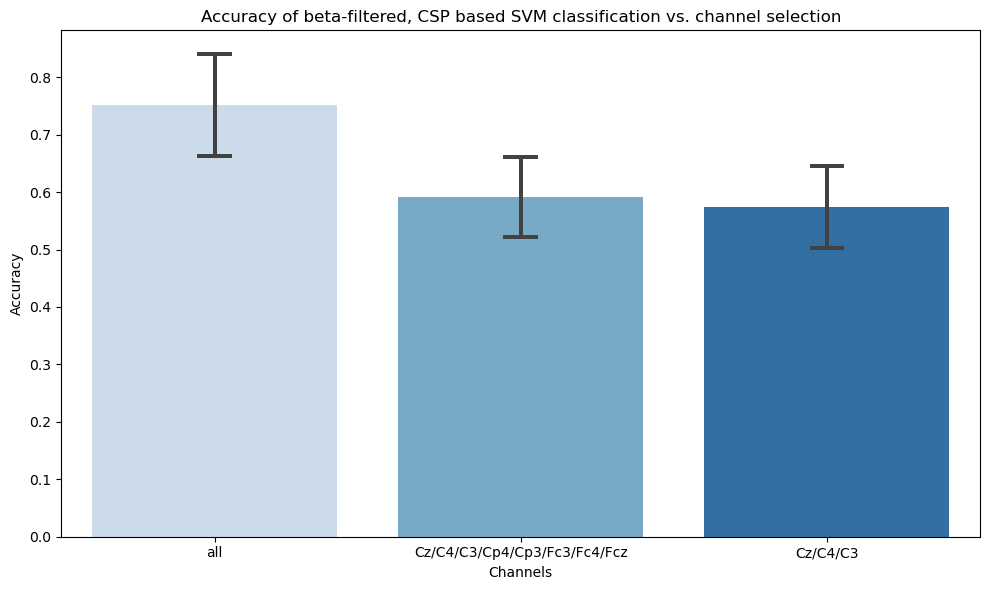

Tested on 109 subjects


In [127]:
plot_svm_accuracy(subject_data,test_channels=test_channels,filter_bands=bands['beta'],subject_range=109)
plot_svm_accuracy(subject_data,test_channels=test_channels,filter_bands=bands['beta'],csp=True,subject_range=109)

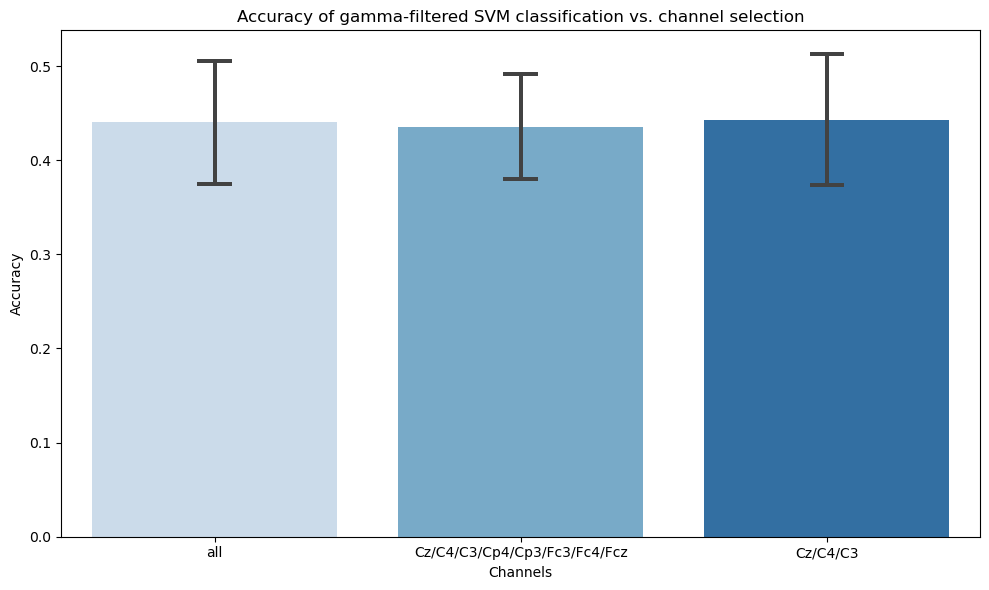

Tested on 109 subjects


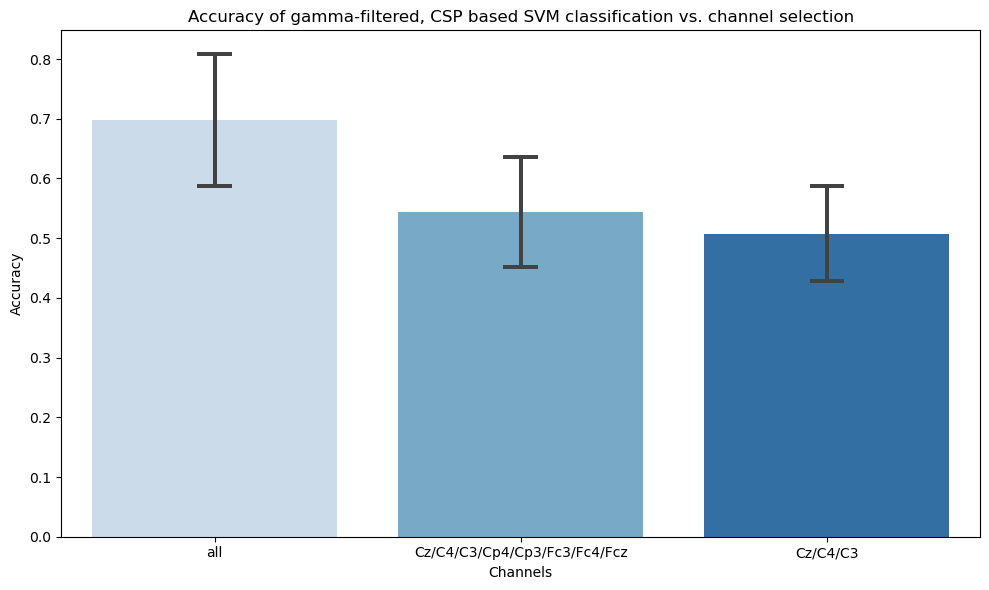

Tested on 109 subjects


In [128]:
plot_svm_accuracy(subject_data,test_channels=test_channels,filter_bands=bands['gamma'],subject_range=109)
plot_svm_accuracy(subject_data,test_channels=test_channels,filter_bands=bands['gamma'],csp=True,subject_range=109)

## SVM Frequency Band Analysis

In [23]:
# Frequency bands (Hz)
freq_bands = {
    "Alpha": (8, 12),
    "Beta": (12, 30),
    "Gamma": (30, 97)
}

num_subjects = 10 
num_trials = 14 

results = {band: [] for band in freq_bands.keys()}  

# Function to compute Power Spectral Density
def compute_psd(eeg_data, sfreq, band):
    fmin, fmax = band
    freqs, psd = welch(eeg_data, sfreq, nperseg=256, axis=1)
    band_power = np.mean(psd[:, (freqs >= fmin) & (freqs <= fmax)], axis=1)
    return band_power  # Shape: (64,)

# Loop over subjects
for subject_id in range(num_subjects):  
    print(f"\nProcessing Subject {subject_id + 1}...")

    for band_name, band_range in freq_bands.items():
        print(f"  Training on {band_name} band...")

        X_band = []
        y = []

        # Extract features for each trial
        for trial in range(num_trials):
            eeg_trial = subject_data[subject_id, trial, :, :]  

            # Assign trial labels (T0 = rest, T1 = real movement, T2 = imagined movement)
            if trial in [2, 4, 6, 8, 10, 12]:  # Real movement trials
                label = 1  # T1
            elif trial in [3, 5, 7, 9, 11, 13]:  # Imagined movement trials
                label = 2  # T2

            band_power = compute_psd(eeg_trial, 160, band_range)  
            X_band.append(band_power)
            y.append(label)

        X_band = np.array(X_band)
        y = np.array(y)

        # Normalize 
        scaler = StandardScaler()
        X_band = scaler.fit_transform(X_band)

        # Train/Test Split (70% train, 30% test)
        X_train, X_test, y_train, y_test = train_test_split(X_band, y, test_size=0.3, random_state=42)

        # Train SVM Model
        svm_band = SVC(kernel='linear', C=1)
        svm_band.fit(X_train, y_train)

        # Test the model
        test_accuracy = svm_band.score(X_test, y_test)
        cv_scores = cross_val_score(svm_band, X_band, y, cv=5)

        results[band_name].append(test_accuracy * 100)

        print(f"    SVM Test Accuracy: {test_accuracy * 100:.2f}%")
        print(f"    Cross-Validation Accuracy: {np.mean(cv_scores) * 100:.2f}% ± {np.std(cv_scores) * 100:.2f}%")

# **Plot SVM Performance Across Subjects**
plt.figure(figsize=(10, 6))
for band_name, accuracies in results.items():
    plt.plot(range(1, num_subjects + 1), accuracies, marker='o', label=f"{band_name} Band")

plt.xlabel("Subject")
plt.ylabel("SVM Test Accuracy (%)")
plt.title("SVM Classification Performance Across Subjects")
plt.legend()
plt.grid(True)
plt.show()

# **Print Average Accuracy Per Band**
print("\n=== Average Accuracy Across Subjects ===")
for band_name, accuracies in results.items():
    print(f"{band_name}: {np.mean(accuracies):.2f}% ± {np.std(accuracies):.2f}%")
plt.figure(figsize=(10, 6))

plt.figure(figsize=(10, 6))
mean_accuracies = [np.mean(acc) for acc in results.values()]
std_accuracies = [np.std(acc) for acc in results.values()]
plt.bar(results.keys(), mean_accuracies, yerr=std_accuracies, capsize=5, alpha=0.75)
plt.xlabel("Frequency Band")
plt.ylabel("SVM Test Accuracy (%)")
plt.title("SVM Classification Performance (Mean ± Std Dev) for 10 subjects")
plt.grid(axis="y")
plt.show()

NameError: name 'label' is not defined

## Power
First is Alpha & Beta Band Power Across Trials for Subject 1, second is Alpha & Beta Band Power Across Trials for All Subjects

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import wfdb

# Define motor movement categories
resting_runs = [1, 2]  
real_movement_runs = [3, 5, 7, 9, 11, 13]  
imagined_movement_runs = [4, 6, 8, 10, 12, 14]  

# Initialize lists for trial-level data
alpha_power_list = []
beta_power_list = []
labels_list = []

# Process only Subject 1
subject = 1  

# Loop through only Subject 1's trials
for trial in range(1, 15):  

    file_path = f"./files/eegmmidb/1.0.0/S{subject:03}/S{subject:03}R{trial:02}.edf"

    try:
        # Read EEG annotations
        annotations = wfdb.rdann(file_path, 'event')
        samples = annotations.sample
        notes = annotations.aux_note

        # Load the EEG data for this trial
        raw = mne.io.read_raw_edf(file_path, preload=True)  # Load EDF file
        df = raw.to_data_frame()  # Convert to DataFrame
        df.set_index(raw.times, inplace=True)  # Set time index

        # Ensure the selected channels exist in the loaded EEG data
        selected_channels = df[motor_channels]

        # Apply bandpass filters
        sos_alpha = butter_bandpass(8, 12, fs, order=10)
        sos_beta = butter_bandpass(13, 30, fs, order=10)

        alpha_df = selected_channels.apply(lambda x: sosfiltfilt(sos_alpha, x))
        beta_df = selected_channels.apply(lambda x: sosfiltfilt(sos_beta, x))

        print(f"Processing trial {trial} for Subject {subject}")
        print(f"Alpha Raw Data Sample:\n{alpha_df.head()}")  # Check if EEG signals change across trials
        print(f"Alpha Variance: {np.var(alpha_df.values, axis=0)}")  # Ensure variance isn't constant
        print(f"Alpha Log Power: {np.log(np.var(alpha_df.values, axis=0))}")  # Ensure log power is changing


        # Compute power per trial (NO AVERAGING)
        alpha_power = np.log(np.var(alpha_df.values, axis=0))  
        beta_power = np.log(np.var(beta_df.values, axis=0))

        # Assign labels based on trial number
        if trial in resting_runs:
            trial_label = 0  # Resting
        elif trial in real_movement_runs:
            trial_label = 1  # Real Movement
        elif trial in imagined_movement_runs:
            trial_label = 2  # Imagined Movement
        else:
            continue  

        # Append the trial-level power values
        alpha_power_list.append(alpha_power.mean())  # Ensure single value per trial
        beta_power_list.append(beta_power.mean())  
        labels_list.append(trial_label)

    except:
        print(f"Skipping missing file: {file_path}")
        continue

# Convert lists to arrays
alpha_power = np.array(alpha_power_list)
beta_power = np.array(beta_power_list)
labels = np.array(labels_list)

# Check label distribution
print("Label Counts:", np.bincount(labels))

# Define conditions
conditions = ["Resting", "Real Movement", "Imagined Movement"]

# **Create lists for each condition**
alpha_data = [alpha_power[labels == i] for i in range(3)]
beta_data = [beta_power[labels == i] for i in range(3)]

print("Alpha Power (Resting):", alpha_power[labels == 0])
print("Alpha Power (Real):", alpha_power[labels == 1])
print("Alpha Power (Imagined):", alpha_power[labels == 2])

print("Beta Power (Resting):", beta_power[labels == 0])
print("Beta Power (Real):", beta_power[labels == 1])
print("Beta Power (Imagined):", beta_power[labels == 2])


# Boxplot for better trial-level visualization
plt.figure(figsize=(10, 6))

# Alpha band boxplot (blue)
plt.boxplot(alpha_data, positions=np.arange(3) - 0.15, widths=0.3, patch_artist=True,
            boxprops=dict(facecolor="blue", alpha=0.5), medianprops=dict(color="black"))

# Beta band boxplot (orange)
plt.boxplot(beta_data, positions=np.arange(3) + 0.15, widths=0.3, patch_artist=True,
            boxprops=dict(facecolor="orange", alpha=0.5), medianprops=dict(color="black"))

# Labels and title
plt.xlabel("Condition")
plt.ylabel("Log Power")
plt.title("Alpha & Beta Band Power Across Trials for Subject 1")
plt.xticks(range(3), conditions)  

# Fix the legend
custom_lines = [
    plt.Line2D([0], [0], color="blue", lw=4, label="Alpha (8-12 Hz)"),
    plt.Line2D([0], [0], color="orange", lw=4, label="Beta (13-30 Hz)")
]
plt.legend(handles=custom_lines)

# Show plot
plt.show()

plt.figure(figsize=(10, 6))

for condition, label in enumerate(conditions):
    plt.scatter(
        [condition] * np.sum(labels == condition),
        alpha_power[labels == condition],
        color="blue", label="Alpha (8-12 Hz)" if condition == 0 else "", alpha=0.7
    )
    plt.scatter(
        [condition] * np.sum(labels == condition),
        beta_power[labels == condition],
        color="orange", label="Beta (13-30 Hz)" if condition == 0 else "", alpha=0.7
    )

plt.xlabel("Condition")
plt.ylabel("Log Power")
plt.title("Alpha & Beta Band Power for Subject 1 (Scatter Plot)")
plt.xticks(range(3), conditions)
plt.legend()
plt.show()

In [ ]:
# Define motor movement categories
resting_runs = [1, 2]  
real_movement_runs = [3, 5, 7, 9, 11, 13]  
imagined_movement_runs = [4, 6, 8, 10, 12, 14]  

# Initialize lists for trial-level data across all subjects
alpha_power_list = []
beta_power_list = []
labels_list = []

# Loop through all 109 subjects
for subject in range(1, 110):  

    # Loop through all trials for the current subject
    for trial in range(1, 15):  
        file_path = f"./files/eegmmidb/1.0.0/S{subject:03}/S{subject:03}R{trial:02}.edf"

        try:
            # Read EEG annotations
            annotations = wfdb.rdann(file_path, 'event')
            samples = annotations.sample
            notes = annotations.aux_note

            # Load the EEG data for this trial
            raw = mne.io.read_raw_edf(file_path, preload=True)  # Load EDF file
            df = raw.to_data_frame()  # Convert to DataFrame
            df.set_index(raw.times, inplace=True)  # Set time index

            # Select motor-related EEG channels
            motor_channels = ["C3..", "C4..", "Cz.."]  # Common motor imagery channels
            selected_channels = df[motor_channels]

            # Apply bandpass filters
            sos_alpha = butter_bandpass(8, 12, raw.info["sfreq"], order=10)
            sos_beta = butter_bandpass(13, 30, raw.info["sfreq"], order=10)

            alpha_df = selected_channels.apply(lambda x: sosfiltfilt(sos_alpha, x))
            beta_df = selected_channels.apply(lambda x: sosfiltfilt(sos_beta, x))

            # Compute power per trial (NO AVERAGING across subjects)
            alpha_power = np.log(np.var(alpha_df.values, axis=0))  
            beta_power = np.log(np.var(beta_df.values, axis=0))

            # Assign labels based on trial number
            if trial in resting_runs:
                trial_label = 0  # Resting
            elif trial in real_movement_runs:
                trial_label = 1  # Real Movement
            elif trial in imagined_movement_runs:
                trial_label = 2  # Imagined Movement
            else:
                continue  

            # Append the trial-level power values
            alpha_power_list.append(alpha_power.mean())  # Mean across selected channels
            beta_power_list.append(beta_power.mean())  
            labels_list.append(trial_label)

        except:
            print(f"Skipping missing file: {file_path}")
            continue

# Convert lists to arrays
alpha_power = np.array(alpha_power_list)
beta_power = np.array(beta_power_list)
labels = np.array(labels_list)

# Check label distribution
print("Label Counts:", np.bincount(labels))

# Define conditions
conditions = ["Resting", "Real Movement", "Imagined Movement"]

# Create lists for each condition
alpha_data = [alpha_power[labels == i] for i in range(3)]
beta_data = [beta_power[labels == i] for i in range(3)]

# Boxplot for better trial-level visualization across all subjects
plt.figure(figsize=(10, 6))

# Alpha band boxplot (blue)
plt.boxplot(alpha_data, positions=np.arange(3) - 0.15, widths=0.3, patch_artist=True,
            boxprops=dict(facecolor="blue", alpha=0.5), medianprops=dict(color="black"))

# Beta band boxplot (orange)
plt.boxplot(beta_data, positions=np.arange(3) + 0.15, widths=0.3, patch_artist=True,
            boxprops=dict(facecolor="orange", alpha=0.5), medianprops=dict(color="black"))

# Labels and title
plt.xlabel("Condition")
plt.ylabel("Log Power")
plt.title("Alpha & Beta Band Power Across Trials for All Subjects")
plt.xticks(range(3), conditions)  

# Fix the legend
custom_lines = [
    plt.Line2D([0], [0], color="blue", lw=4, label="Alpha (8-12 Hz)"),
    plt.Line2D([0], [0], color="orange", lw=4, label="Beta (13-30 Hz)")
]
plt.legend(handles=custom_lines)

# Show plot
plt.show()


# Scatter plot to see trial-level variation across subjects
plt.figure(figsize=(10, 6))

for condition, label in enumerate(conditions):
    plt.scatter(
        [condition] * np.sum(labels == condition),
        alpha_power[labels == condition],
        color="blue", label="Alpha (8-12 Hz)" if condition == 0 else "", alpha=0.7
    )
    plt.scatter(
        [condition] * np.sum(labels == condition),
        beta_power[labels == condition],
        color="orange", label="Beta (13-30 Hz)" if condition == 0 else "", alpha=0.7
    )

plt.xlabel("Condition")
plt.ylabel("Log Power")
plt.title("Alpha & Beta Band Power Across Trials for All Subjects (Scatter Plot)")
plt.xticks(range(3), conditions)
plt.legend()
plt.show()
